<a href="https://colab.research.google.com/github/hindxb/FDS/blob/main/Notebooks/Project/FDS_GRU_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

GRU Model Creation
---
By Hind Alzarooni U25102248

Step 1 - Define target output
---

The main objective is to predict SPEED_FILLED (target).

---
Based on the current data:
- road segment
- direction
- timestamp
- speed_filled (cleaned version of speed with no missing values)
- etc.

the chosen target objective is the most suitable as its directly correlated to urban traffic flow and congestion levels.

We try to **predict the next traffic speed for each segment using previous time steps**. Thus, the model learns whether the traffic is staying stable, improving or worsening.

We will use multivariate time series prediction (multiple features) for better prediction.


Step 2 - Prepare, Clean and Sort Data Correctly (Safety CHECK)
---
- Clean time order within each segment is required
- Same global start/end time across segements is not required, becuase the model is trying to learn patterns from each segment (uncombined) so its fine.

0. Load data
1. Parse time
2. Sort data
3. Filter segments with enough rows
4. Create **temporal features** (time-based features extraction)
5. Cyclical encoding for **hour and day of week features**
6. Keep only meaningful columns (features)
7. Convert to numeric columns
8. Handle missing values
9. Encode **categorical features** (feature transformation)
10. Cleanup

In [ ]:
import numpy as np                 #for numerical operations such as sine and cosine
import pandas as pd                #for data loading and table dataframe manipulation
from google.colab import drive

#mount Google Drive
drive.mount('/content/drive')

#load file
file_path = '/content/drive/MyDrive/datasets/chicago_traffic_imputed.csv'
df = pd.read_csv(file_path)        #read the CSV into a pandas data frame

print("Original shape:", df.shape) #print rows and cols in the original dataframe
print("\nOriginal columns:")
print(df.columns.tolist())         #convert cols names into Python list and print them


# 1. PARSE TIME
#==================================
df['TIME'] = pd.to_datetime(df['TIME'], dayfirst=True, errors='coerce')  #convert TIME to datetime assuming DD/MM/YY HH:mm format and set invalid values to NaT
df = df.dropna(subset=['TIME']).copy()                                   #remove rows where TIME couldn't be parsed, then create a copy of the cleaned dataframe

# 2. SORT DATA
#==================================
df = df.sort_values(['SEGMENT_ID', 'TIME']).reset_index(drop=True)       #sort rows by SEGMENT_ID then by TIME, then resent the index

# 3. FILTER SEGMENTS WITH ENOUGH ROWS
#we use a stronger threshold because sequence models
#need enough history per segment.
#==================================
min_rows_per_segment = 60          #defining min number of rows required per segment

segment_sizes = df.groupby('SEGMENT_ID').size()                                #count of rows per segment
valid_segments = segment_sizes[segment_sizes >= min_rows_per_segment].index    #keep only segment IDs whose rows meets the min threshold

df = df[df['SEGMENT_ID'].isin(valid_segments)].copy()                          #filter the dataframe to keep valid segments only then make a copy
df = df.sort_values(['SEGMENT_ID', 'TIME']).reset_index(drop=True)             #resort the filtered dataframe by segment and time, then reset index

print("\nShape after filtering segments:", df.shape)
print("Number of valid segments:", df['SEGMENT_ID'].nunique())                 #number of unique remaining segments


# 4. CREATE TEMPORAL FEATURES
#==================================
df['HOUR'] = df['TIME'].dt.hour                 #extract hour from TIME column
df['DAY_OF_WEEK'] = df['TIME'].dt.dayofweek     #extract day of week from TIME column; Mon=0, Sun=6

df['is_weekend'] = df['DAY_OF_WEEK'].isin([5, 6]).astype(int)                 #create a binary feature that is 1 for Sat or Sun, else 0
df['is_rush_hour'] = df['HOUR'].isin([7, 8, 9, 16, 17, 18]).astype(int)       #create a binary feature that is 1 during day time (rush hours), else 0

# 5. CYCLICAL ENCODING FOR HOUR AND DAY OF WEEK
#==============================================
df['hour_sin'] = np.sin(2 * np.pi * df['HOUR'] / 24)                          #encode hour cyclically using sin to preserve time of day circularity
df['hour_cos'] = np.cos(2 * np.pi * df['HOUR'] / 24)                          #encode hour cyclically using cosine

#cyclical encoding for day of week
df['dow_sin'] = np.sin(2 * np.pi * df['DAY_OF_WEEK'] / 7)                     #encode day of week cyclicaly using sin
df['dow_cos'] = np.cos(2 * np.pi * df['DAY_OF_WEEK'] / 7)                     #encode day of week cyclicaly using cos


# 6. KEEP ONLY MEANINGFUL COLUMNS
#drop: redundant IDs, raw lat/lon, text streets,
#duplicate time, raw SPEED (leaky), raw hour/day of week/month
#====================================
candidate_cols = [
    'TIME',
    'SEGMENT_ID',

    #target
    'SPEED_FILLED',

    #traffic signals
    'BUS_COUNT',
    'MESSAGE_COUNT',
    'LENGTH',

    #missing indicators
    'SPEED_WAS_MISSING',

    #direction (will be one-hot encoded later)
    'DIRECTION',

    #temporal binary
    'is_weekend',
    'is_rush_hour',

    #temporal cyclical (already encoded so raw HOUR, DAY_OF_WEEK, MONTH ae dropped)
    'hour_sin',
    'hour_cos',
    'dow_sin',
    'dow_cos',
]

existing_cols = [col for col in candidate_cols if col in df.columns]    #keep only those candidate columns that actually exist in the data frame
df_model = df[existing_cols].copy()                                     #create a new dataframe containing only the selcted existing columns

print("\nShape after selecting columns:", df_model.shape)
print("Columns kept:")
print(df_model.columns.tolist())


# 7. CONVERT TO NUMERIC COLUMNS
#==================================
numeric_cols = [                    #list of cols expected to be numeric
    'SPEED_FILLED',
    'BUS_COUNT',
    'MESSAGE_COUNT',
    'LENGTH',
    'SPEED_WAS_MISSING',
    'is_weekend',
    'is_rush_hour',
    'hour_sin',
    'hour_cos',
    'dow_sin',
    'dow_cos'
    'speed_lag_24',
    'segment_speed_mean',
    'month_sin',
    'month_cos',
]

for col in numeric_cols:
    if col in df_model.columns:     #check whether the current sol exists in df_model before converting
        df_model[col] = pd.to_numeric(df_model[col], errors='coerce')         #convert col to numeric and replace invalid values with Nan


# 8. HANDLE MISSING VALUES
#add missing indicators before filling counts with 0.
#====================================
if 'BUS_COUNT' in df_model.columns:
    df_model['BUS_COUNT_MISSING'] = df_model['BUS_COUNT'].isna().astype(int)          #create a binary indicator (T/F) showing where BUS_COUNT was missing
    df_model['BUS_COUNT'] = df_model['BUS_COUNT'].fillna(0)                           #replace missing BUS_COUNT values with 0

if 'MESSAGE_COUNT' in df_model.columns:
    df_model['MESSAGE_COUNT_MISSING'] = df_model['MESSAGE_COUNT'].isna().astype(int)  #create a binary indicator (T/F) showing where MESSAGE_COUNT was missing
    df_model['MESSAGE_COUNT'] = df_model['MESSAGE_COUNT'].fillna(0)                   #replace missing MESSAGE_COUNT values with 0

if 'SPEED_WAS_MISSING' in df_model.columns:
    df_model['SPEED_WAS_MISSING'] = df_model['SPEED_WAS_MISSING'].fillna(0)           #this was imputed to cread SPEED_FILLED, whether it's important or not is discussed in the text just above this code block

#target must exist
df_model = df_model.dropna(subset=['SPEED_FILLED']).copy()                            #remove rows where target SPEED_FILLED is missing, then create a copy


# 9. ENCODE CATEGORICAL FEATURES
#====================================
categorical_cols = []                                                                 #initialize an empty list to store columns that need encoding

if 'DIRECTION' in df_model.columns:
    categorical_cols.append('DIRECTION')

for col in categorical_cols:
    df_model[col] = df_model[col].astype(str)                                         #convert the categorical col to string before one-hot encoding

if categorical_cols:                                                                  #check whether there is at least one categorical col to encode
    df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)    #one-hot encode categorical col and dropthe first category to reduce redundancy

# 10. CLEANUP
#we avoid aggressive cleanup on all columns unless needed
#=========================================================
required_cols = ['TIME', 'SEGMENT_ID', 'SPEED_FILLED']                                #defining cols that must not be missing
df_model = df_model.dropna(subset=required_cols).reset_index(drop=True)               #drop rows missing any required col and reset index

print("\nFinal shape after preprocessing:", df_model.shape)
print("\nFinal columns:")
print(df_model.columns.tolist())    #print final list of cols after all transformations

display(df_model.head())            #display the first few rows of the final preprocessed dataframe

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_66564/529825092.py:10: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)        #read the CSV into a pandas data frame


Original shape: (1018752, 25)

Original columns:
['TIME', 'SEGMENT_ID', 'SPEED', 'STREET', 'DIRECTION', 'FROM_STREET', 'TO_STREET', 'LENGTH', 'STREET_HEADING', 'COMMENTS', 'BUS_COUNT', 'MESSAGE_COUNT', 'HOUR', 'DAY_OF_WEEK', 'MONTH', 'RECORD_ID', 'START_LATITUDE', 'START_LONGITUDE', 'END_LATITUDE', 'END_LONGITUDE', 'START_LOCATION', 'END_LOCATION', 'TIME_ORIGINAL', 'SPEED_WAS_MISSING', 'SPEED_FILLED']

Shape after filtering segments: (1018752, 25)
Number of valid segments: 56

Shape after selecting columns: (1018752, 14)
Columns kept:
['TIME', 'SEGMENT_ID', 'SPEED_FILLED', 'BUS_COUNT', 'MESSAGE_COUNT', 'LENGTH', 'SPEED_WAS_MISSING', 'DIRECTION', 'is_weekend', 'is_rush_hour', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']

Final shape after preprocessing: (1018752, 17)

Final columns:
['TIME', 'SEGMENT_ID', 'SPEED_FILLED', 'BUS_COUNT', 'MESSAGE_COUNT', 'LENGTH', 'SPEED_WAS_MISSING', 'is_weekend', 'is_rush_hour', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'BUS_COUNT_MISSING', 'MESSAGE_

,TIME,SEGMENT_ID,SPEED_FILLED,BUS_COUNT,MESSAGE_COUNT,LENGTH,SPEED_WAS_MISSING,is_weekend,is_rush_hour,hour_sin,hour_cos,dow_sin,dow_cos,BUS_COUNT_MISSING,MESSAGE_COUNT_MISSING,DIRECTION_SB,DIRECTION_WB
0,2025-04-28 12:20:00,144,25.0,0,0,0.5,1,0,0,1.224647e-16,-1.000000,0.0,1.0,0,0,True,False
1,2025-04-28 12:30:00,144,25.5,0,0,0.5,1,0,0,1.224647e-16,-1.000000,0.0,1.0,0,0,True,False
2,2025-04-28 12:40:00,144,25.0,3,21,0.5,0,0,0,1.224647e-16,-1.000000,0.0,1.0,0,0,True,False
3,2025-04-28 12:50:00,144,25.5,0,0,0.5,1,0,0,1.224647e-16,-1.000000,0.0,1.0,0,0,True,False
4,2025-04-28 13:01:00,144,26.0,1,7,0.5,0,0,0,-2.588190e-01,-0.965926,0.0,1.0,0,0,True,False


We are taking traffic data and creating new features that can help us understand what happened in the past. Thus we can predict what will happen in the future based on this past.


---
11. Copy and sort
- Make a copy of data to preserve the original data.
- Arrange the data so that each road segment is grouped together.
- Inside each segment, time is ordered (past to future).
12. Create **lag features**
- By choosing few time steps from the past [1,2,3,6,12,24].
- For each road segment we take SPEED_FILLED column and shift it by each of these offsets, so that past speed values are copied into the current row as a new values.
- Loop through the list [1,2,3,6,12,24] to create columns
- Now we have new columns; speed_lag_1, speed_lag_2, speed_lag_3, speed_lag_6, etc.
- Inside these columns we have shifted speeds from the past, taken from SPEED_FILL.
13. Segment-level statistical **mean feature**
- For each road segment, we take the first 80% of records (ordered from past to future) and mark them as training data to avoid using future data (the remaining 20%).
- We are trying to predict based on historical data.
- For each road segment, we take SPEED_FILLED values, but only from the first 80% of time. Based on these SPEED_FILLED values, we compute the average speed of each segment to create a new feature (segment_speed_mean) that is shared across all rows of the same segment.
14. Add seasonality: **month features**
- Traffic may change based on the time of year, so we encode months cyclically.
- This ensures adjacent months are close to each other.
15. Add **rolling features**
- To summarize recent short and long term traffic behavior.
- This is done by computing the average of the last 6 and 12 past values from SPEED_FILLED (within the same segment).
- Also compute the standard deviation of the last 12 steps.
16. Add **difference features**
- Compute the difference between current and past values.
- This helps interpret whether speed is increasing or decreasing (trend).
17. Collect all required features and remove incomplete rows.



In [ ]:
# 11. DATA PREPARATION AND TEMPORAL ORDERING
#===========================================
df = df_model.copy()                                                                    #create a copy so changes do not affect
df = df.sort_values(['SEGMENT_ID', 'TIME']).reset_index(drop=True)                      #sort the dataframe by segment and timestamp, then reset row numbering


# 12. SEGMENT-LEVEL STATISTICAL FEATURES: extended lags
#===========================================
for lag in [1, 2, 3, 6, 12, 24]:                                                        #loop through selected lag values to capture a longer historical pattern
    df[f'speed_lag_{lag}'] = df.groupby('SEGMENT_ID')['SPEED_FILLED'].shift(lag)        #for each segment, shift SPEED_FILLED downward by the lag amount to create a past-speed feature. shift(lag) means take the value from lag rows before

# 13. SEGEMNT SPEED MEAN: uses only training portion (first 80% per segment)
#===========================================
train_mask = df.groupby('SEGMENT_ID')['TIME'].transform(lambda x: x <= x.quantile(0.8))     #create a boolean mask of rows whose time is within the first 80% of timestamps inside each segment
segment_mean_train = df[train_mask].groupby('SEGMENT_ID')['SPEED_FILLED'].mean()            #compute the mean speed for eah segment using only rows marked as training
df['segment_speed_mean'] = df['SEGMENT_ID'].map(segment_mean_train)                         #map each segment ID to its training mean speed and store it as a new feature


# 14. TEMPORAL AND SEASONAL ENCODING
#=========================================
df['month_sin'] = np.sin(2 * np.pi * df['TIME'].dt.month / 12)                              #encode month as a sin value to represent yearly cyclic seasonality
df['month_cos'] = np.cos(2 * np.pi * df['TIME'].dt.month / 12)                              #encode month as a cos value to complement the sin encoding


# 15. ROLLING AND TREND BASED FEATURES
#=========================================
df['speed_roll_mean_6']  = df.groupby('SEGMENT_ID')['SPEED_FILLED'].transform(lambda x: x.shift(1).rolling(6,  min_periods=2).mean())     #for each segment, compute the rolling mean of the previous 6 speed values, using at least 2 past observations and excluding the current row with shift(1), rolling(6).mean(), means average over the last 6 past observations
df['speed_roll_std_6']   = df.groupby('SEGMENT_ID')['SPEED_FILLED'].transform(lambda x: x.shift(1).rolling(6,  min_periods=2).std())      #for each segment, compute the rolling standard deviation of the previous 6 speed values, uisng at least 2 past observations and excluding current row
df['speed_roll_mean_12'] = df.groupby('SEGMENT_ID')['SPEED_FILLED'].transform(lambda x: x.shift(1).rolling(12, min_periods=4).mean())     #for each segment, compute rolling mean of the previous 12 speed values, using at least 4 observations and excluding the current row

# 16. SPEED DIFFERENCE FEATURE
#=========================================
df['speed_diff_1'] = df.groupby('SEGMENT_ID')['SPEED_FILLED'].diff(1)                       #for each segment, compute the difference between current and immediately previous speed. diff(1) means current value minus previous value
df['speed_diff_3'] = df.groupby('SEGMENT_ID')['SPEED_FILLED'].diff(3)                       #for each segment, compute the difference between the current and the speed value of 3 steps earlier

# 17. COLLECTION OF REQUIRED FEATURES
#drop rows with missing lag values
#=========================================
lag_cols = [f'speed_lag_{l}' for l in [1,2,3,6,12,24]] + \
           ['speed_roll_mean_6','speed_roll_std_6','speed_roll_mean_12',
            'speed_diff_1','speed_diff_3']                                                  #create a list for all lag feature names, add rolling statistic featuresto the list of required historical features, add speed difference features too

#data cleaning for model input
df = df.dropna(subset=lag_cols).reset_index(drop=True)                                      #remove rows where any required lag/rolling/difference feature is missing, then reset index. removes the first wors in each segment becasue they dont yet have enough history
print("Shape after lag/rolling features:", df.shape)                                        #dataframe shape after creating features and dropping incomplete rows

Shape after lag/rolling features: (1017408, 31)


Step 4 - Feature Type Validation and Data Cleaning
---
18. Final numeric check
19. Final cleanup

In [ ]:
#initial checking
print("\nUsing dataframe after short-term lag creation")
print("Current shape:", df.shape)
print("Columns available:")
print(df.columns.tolist())    #print all the names of all columns in the dataframe as a list


# 18. FINAL NUMERIC CHECK
#make sure all model columns except TIME (datetime object) are numeric where needed.
#=========================================================
numeric_cols = [
    'SPEED_FILLED',
    'BUS_COUNT',
    'MESSAGE_COUNT',
    'LENGTH',
    'SPEED_WAS_MISSING',
    'is_weekend',
    'is_rush_hour',
    'hour_sin',
    'hour_cos',
    'dow_sin',
    'dow_cos',
    'BUS_COUNT_MISSING',
    'MESSAGE_COUNT_MISSING',

    #short-term speed lags
    'speed_lag_1',            #these are already created so they must be numeric for sure, adding or removing them won't hurt
    'speed_lag_2',
    'speed_lag_3'
]

for col in numeric_cols:
    if col in df.columns:     #check whether the current column actually exists in the dataframe
        df[col] = pd.to_numeric(df[col], errors='coerce')  #convert the column to numeric and replace invalid values with NaN

#also make sure one-hot encoded direction columns are numeric
dummy_cols = [col for col in df.columns if col.startswith('DIRECTION_')]    #find all columns related to direction
for col in dummy_cols:                                                      #for each of these columns
    df[col] = pd.to_numeric(df[col], errors='coerce')                       #convert each direction to numeric (0/1)

print("\nNumeric conversion check done")
print("Current shape:", df.shape)       #the dataframe shape after numeric conversion


# 19. FINAL CLEANUP
#========================================
before = df.shape[0]                    #store the number of rows before cleanup, so the removed count can be reported later

required_cols_for_model = [             #list of columns that must exist and must not be missing a row to be usable for the models
    'TIME',
    'SEGMENT_ID',
    'SPEED_FILLED',
    'speed_lag_1',
    'speed_lag_2',
    'speed_lag_3'
]

df = df.dropna(subset=required_cols_for_model).reset_index(drop=True)             #remove rows missing any required columns and reset indexing

after = df.shape[0]

print("\nRows before final cleanup:", before)
print("Rows after final cleanup :", after)
print("Rows removed             :", before - after)

print("\nFinal columns:")
print(df.columns.tolist())              #final list of column names after clean up

display(df.head())                      #display the first few rows of the final cleaned dataframe


Using dataframe after short-term lag creation
Current shape: (1017408, 31)
Columns available:
['TIME', 'SEGMENT_ID', 'SPEED_FILLED', 'BUS_COUNT', 'MESSAGE_COUNT', 'LENGTH', 'SPEED_WAS_MISSING', 'is_weekend', 'is_rush_hour', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'BUS_COUNT_MISSING', 'MESSAGE_COUNT_MISSING', 'DIRECTION_SB', 'DIRECTION_WB', 'speed_lag_1', 'speed_lag_2', 'speed_lag_3', 'speed_lag_6', 'speed_lag_12', 'speed_lag_24', 'segment_speed_mean', 'month_sin', 'month_cos', 'speed_roll_mean_6', 'speed_roll_std_6', 'speed_roll_mean_12', 'speed_diff_1', 'speed_diff_3']

Numeric conversion check done
Current shape: (1017408, 31)

Rows before final cleanup: 1017408
Rows after final cleanup : 1017408
Rows removed             : 0

Final columns:
['TIME', 'SEGMENT_ID', 'SPEED_FILLED', 'BUS_COUNT', 'MESSAGE_COUNT', 'LENGTH', 'SPEED_WAS_MISSING', 'is_weekend', 'is_rush_hour', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'BUS_COUNT_MISSING', 'MESSAGE_COUNT_MISSING', 'DIRECTION_SB', 'D

,TIME,SEGMENT_ID,SPEED_FILLED,BUS_COUNT,MESSAGE_COUNT,LENGTH,SPEED_WAS_MISSING,is_weekend,is_rush_hour,hour_sin,...,speed_lag_12,speed_lag_24,segment_speed_mean,month_sin,month_cos,speed_roll_mean_6,speed_roll_std_6,speed_roll_mean_12,speed_diff_1,speed_diff_3
0,2025-04-28 16:20:00,144,20.5,0,0,0.5,1,0,1,-0.866025,...,28.0,25.0,24.835616,0.866025,-0.5,20.750000,1.224745,20.916667,-1.5,0.75
1,2025-04-28 16:30:00,144,19.0,3,19,0.5,0,0,1,-0.866025,...,22.0,25.5,24.835616,0.866025,-0.5,20.500000,1.060660,20.291667,-1.5,0.00
2,2025-04-28 16:40:00,144,20.0,2,10,0.5,0,0,1,-0.866025,...,16.0,25.0,24.835616,0.866025,-0.5,20.125000,1.137431,20.041667,1.0,-2.00
3,2025-04-28 16:50:00,144,17.0,4,20,0.5,0,0,1,-0.866025,...,19.5,25.5,24.835616,0.866025,-0.5,20.041667,1.122683,20.375000,-3.0,-3.50
4,2025-04-28 17:01:00,144,26.0,1,4,0.5,0,0,1,-0.965926,...,23.0,26.0,24.835616,0.866025,-0.5,19.583333,1.685724,20.166667,9.0,7.00


Step 5 - Train/Test Splits Per Segment and Scaling
---

- Sort by time then take first 80% of each segment (training data) and last 20% (testing data). This way we ensure that we train on past data and test on future data.
- Scaling comes after splitting to avoid using test information casuing cheating in model


---
20. Train/test split per segment
21. Define feature columns
22. Scale features and target


In [ ]:
# 20. TRAIN / TEST SPLIT PER SEGMENT
#pandas and numpy were imported before,
#but still added them again for clarity
#==================================
from sklearn.preprocessing import MinMaxScaler      #for scaling values between 0 and 1
import numpy as np                                  #for numerical operations
import pandas as pd                                 #for dataframe operations

sequence_length = 24                                #define sequence length used later for sequence creation
split_ratio = 0.8                                   #set 80% of each segment for training

train_parts = []                                    #empty list to later store training parts from each segment
test_parts = []                                     #empty list to later store testing parts from each segment

for segment in df['SEGMENT_ID'].unique():           #loop through each unique segment
    segment_df = df[df['SEGMENT_ID'] == segment].sort_values('TIME').copy()   #select a segment and sort by time
    n = len(segment_df)                             #get count of rows in this segment

    split_idx = int(n * split_ratio)                #compute row index where trainign ends and testing begins

    #require enough rows for both train and test after sequence creation
    if split_idx <= sequence_length or (n - split_idx) <= sequence_length:    #skip segments that are too short for sequences
        continue

    train_parts.append(segment_df.iloc[:split_idx].copy())  #add 1st 80% of this segment to training data
    test_parts.append(segment_df.iloc[split_idx:].copy())   #add the last 20% of this segment to testing data

train_df = pd.concat(train_parts, axis=0).reset_index(drop=True)    #combine all segment training parts itno one dataframe
test_df = pd.concat(test_parts, axis=0).reset_index(drop=True)      #combine all segment testing parts into one dataframe

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
print("Train segments:", train_df['SEGMENT_ID'].nunique())
print("Test segments :", test_df['SEGMENT_ID'].nunique())           #number of training and tetsing segments should be same because I am taking percentage of rows from each segment then combine all rows based on whether training or testing


# 21. DEFINE FEATURE COLUMNS
#keep only the real predictor features.
#No TIME, SEGMENT_ID, or target as normal predictors
#=========================================================
feature_cols = [col for col in df.columns if col not in ['TIME', 'SEGMENT_ID', 'SPEED_FILLED']]

print("\nNumber of predictor features:", len(feature_cols))
print("Predictor columns:")
print(feature_cols)

# 22. SCALE FEATURES AND TARGET
#fit scalers on training data only
#==========================================================
feature_scaler = MinMaxScaler()     #create a scaler object for input features
target_scaler = MinMaxScaler()      #create a seperate scaler object for the target column

train_df[feature_cols] = feature_scaler.fit_transform(train_df[feature_cols])     #fit is to learn min and max from features and transform is to scale them to 0-1, then replace original values with scaled ones
test_df[feature_cols] = feature_scaler.transform(test_df[feature_cols])           #scale using min and max from training and reuse them for testing, then scale testing based on them, because tesing must behave like unseen future data

train_df[['SPEED_FILLED']] = target_scaler.fit_transform(train_df[['SPEED_FILLED']])    #learn min and max of speed from training and scale them
test_df[['SPEED_FILLED']] = target_scaler.transform(test_df[['SPEED_FILLED']])          #use same min and max from training and scale

print("\nScaling done")

Train shape: (813893, 31)
Test shape : (203515, 31)
Train segments: 56
Test segments : 56

Number of predictor features: 28
Predictor columns:
['BUS_COUNT', 'MESSAGE_COUNT', 'LENGTH', 'SPEED_WAS_MISSING', 'is_weekend', 'is_rush_hour', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'BUS_COUNT_MISSING', 'MESSAGE_COUNT_MISSING', 'DIRECTION_SB', 'DIRECTION_WB', 'speed_lag_1', 'speed_lag_2', 'speed_lag_3', 'speed_lag_6', 'speed_lag_12', 'speed_lag_24', 'segment_speed_mean', 'month_sin', 'month_cos', 'speed_roll_mean_6', 'speed_roll_std_6', 'speed_roll_mean_12', 'speed_diff_1', 'speed_diff_3']

Scaling done


##GRU Model

###Features used:

| Feature Category               | Features                                                                       |
| ------------------------------ | ------------------------------------------------------------------------------ |
| **Traffic Features**           | BUS_COUNT, MESSAGE_COUNT, LENGTH                                               |
| **Temporal Features**          | is_weekend, is_rush_hour, hour_sin, hour_cos, dow_sin, dow_cos                 |
| **Missing Indicators**         | SPEED_WAS_MISSING, BUS_COUNT_MISSING, MESSAGE_COUNT_MISSING                    |
| **Historical (Lag) Features**  | speed_lag_1, speed_lag_2, speed_lag_3, speed_lag_6, speed_lag_12, speed_lag_24 |
| **Trend & Rolling Features**   | speed_roll_mean_6, speed_roll_std_6, speed_roll_mean_12                        |
| **Speed Change Features**      | speed_diff_1, speed_diff_3                                                     |
| **Spatial / Context Features** | segment_speed_mean, DIRECTION (one-hot encoded)                                |


###Model Architecture:

The GRU model is designed to predict the next traffic speed value using a sequence of the previous 24 timesteps and it uses stacked GRU layers to learn  traffic patterns.

| Layer | Configuration | Purpose |
|---|---|---|
| Input | 24 timesteps × selected features | Provides historical traffic sequence to the model |
| GRU Layer 1 | 128 units, return_sequences=True | Learns temporal patterns and passes full sequence to next GRU layer |
| Batch Normalization | — | Stabilizes training |
| Dropout | 0.25 | Reduces overfitting |
| GRU Layer 2 | 64 units, return_sequences=False | Summarizes temporal information into one representation |
| Batch Normalization | — | Stabilizes learned representation |
| Dropout | 0.25 | Reduces overfitting |
| Dense Layer | 32 neurons, ReLU | Learns non-linear relationships |
| Dropout | 0.15 | Light regularization before output |
| Output Layer | Dense(1) | Produces one predicted speed value |

The model is trained using the Adam optimizer with Huber loss, which is suitable for traffic data because it is less sensitive to extreme outliers than MSE.

Final training shape: (651102, 31)
Validation shape    : (162791, 31)
Training segments   : 56
Validation segments : 56

Sequence shapes
X_train shape: (649758, 24, 28)
y_train shape: (649758,)
X_val shape  : (161447, 24, 28)
y_val shape  : (161447,)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 24, 128)        │        60,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 24, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,801 (393.75 KB)

 Trainable params: 100,417 (392.25 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/150
5076/5077 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - loss: 0.0679 - mae: 0.2309 - mse: 0.1548
Epoch 1: val_loss improved from None to 0.00361, saving model to /content/drive/MyDrive/datasets/best_gru_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/datasets/best_gru_model.keras
5077/5077 ━━━━━━━━━━━━━━━━━━━━ 708s 138ms/step - loss: 0.0215 - mae: 0.1253 - mse: 0.0460 - val_loss: 0.0036 - val_mae: 0.0613 - val_mse: 0.0072 - learning_rate: 5.0000e-04
Epoch 2/150
5076/5077 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - loss: 0.0035 - mae: 0.0594 - mse: 0.0071
Epoch 2: val_loss improved from 0.00361 to 0.00269, saving model to /content/drive/MyDrive/datasets/best_gru_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/datasets/best_gru_model.keras
5077/5077 ━━━━━━━━━━━━━━━━━━━━ 646s 127ms/step - loss: 0.0033 - mae: 0.0564 - mse: 0.0066 - val_loss: 0.0027 - val_mae: 0.0493 - val_mse: 0.0054 - learning_rate: 5.0000e-04
Epoch 3/150
5076/5077 ━━━━━━━━━━━━━━━━━

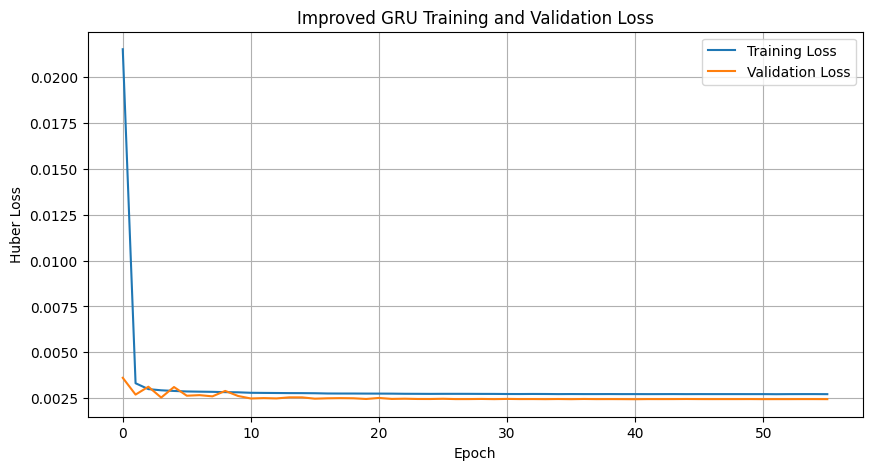

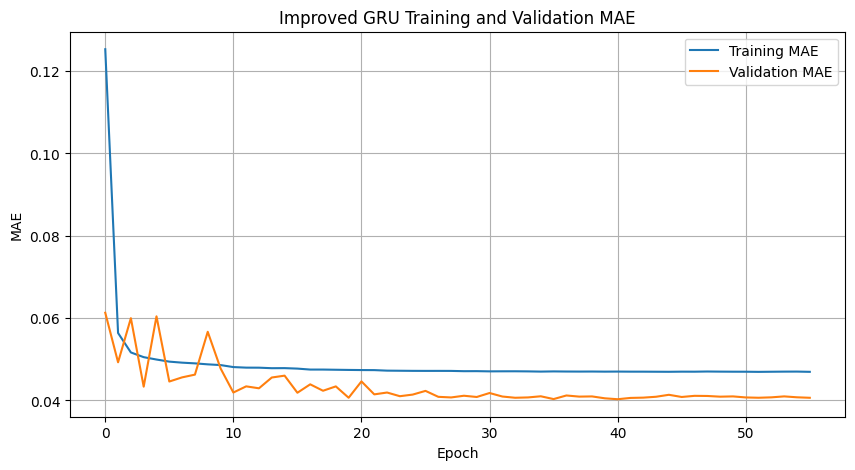

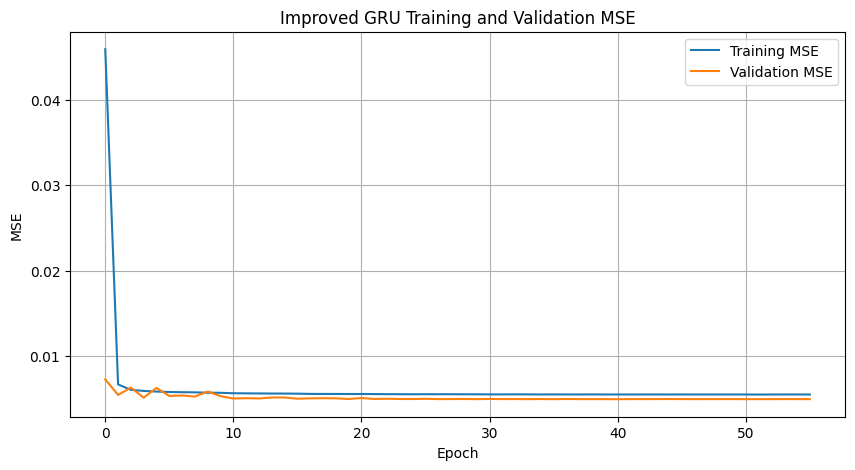

In [ ]:

# 23. CREATE SEQUENCES FOR GRU
# numpy: numerical operations and array handling
# pandas: data manipulation and preprocessing
# matplotlib: visualization of training and evaluation results

# tensorflow.keras:
# - Sequential: builds the model layer-by-layer
# - GRU: captures temporal dependencies in traffic data
# - Dense: performs final prediction (regression output)
# - Dropout: reduces overfitting by randomly disabling neurons
# - BatchNormalization: stabilizes and speeds up training

# Callbacks:
# - EarlyStopping: stops training when validation stops improving
# - ReduceLROnPlateau: lowers learning rate when progress slows
# - ModelCheckpoint: saves the best model during training

# Optimizer:
# - Adam: adaptive optimizer for stable and efficient learning

# Loss:
# - Huber: robust to outliers in traffic data (better than MSE for noisy speeds)

# Metrics:
# - MSE, MAE, R²: used to evaluate prediction performance
# =========================================================
import numpy as np                #numpy: array handling
import pandas as pd               #pandas: data manipulation
import matplotlib.pyplot as plt   #matplotlib: visualization

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sequence_length = 24

# Create sequences per segment using a sliding window
# Uses previous `sequence_length` timesteps to predict next speed
# Preserves temporal order within each road segment

def create_sequences_by_segment(data, feature_cols, target_col, sequence_length):
    X, y = [], []

    for segment in data['SEGMENT_ID'].unique():
        segment_df = data[data['SEGMENT_ID'] == segment].sort_values('TIME').copy()

        X_values = segment_df[feature_cols].values
        y_values = segment_df[target_col].values

        for i in range(sequence_length, len(segment_df)):
            X.append(X_values[i-sequence_length:i])
            y.append(y_values[i])

    return np.array(X), np.array(y)



# 24. CREATE VALIDATION SPLIT FROM TRAIN DATA
# Creates an 80/20 validation split from the training data
# The split is done separately for each road segment
# Rows are sorted by TIME so the model trains on earlier records
# and validates on later records, matching real forecasting behavior
# Segments with too few rows are skipped because they cannot form
# valid 24-step sequences for both training and validation
# Finally, all segment-level splits are combined into final
# training and validation DataFrames
# =========================================================

train_final_parts = []
val_parts = []

val_ratio = 0.2

for segment in train_df['SEGMENT_ID'].unique():
    segment_df = train_df[train_df['SEGMENT_ID'] == segment].sort_values('TIME').copy()
    n = len(segment_df)

    split_idx = int(n * (1 - val_ratio))

    if split_idx <= sequence_length or (n - split_idx) <= sequence_length:
        continue

    train_final_parts.append(segment_df.iloc[:split_idx].copy())
    val_parts.append(segment_df.iloc[split_idx:].copy())

train_final_df = pd.concat(train_final_parts, axis=0).reset_index(drop=True)
val_df = pd.concat(val_parts, axis=0).reset_index(drop=True)

print("Final training shape:", train_final_df.shape)
print("Validation shape    :", val_df.shape)
print("Training segments   :", train_final_df['SEGMENT_ID'].nunique())
print("Validation segments :", val_df['SEGMENT_ID'].nunique())



# 25. CREATE GRU INPUTS
# Defines target variable (SPEED_FILLED)
# Converts data into sequences (X) and next-step targets (y)
# X: previous 24 timesteps of features
# y: next traffic speed to predict
# Done separately for training and validation sets
# =========================================================

target_col = 'SPEED_FILLED'

X_train, y_train = create_sequences_by_segment(
    train_final_df,
    feature_cols,
    target_col,
    sequence_length
)

X_val, y_val = create_sequences_by_segment(
    val_df,
    feature_cols,
    target_col,
    sequence_length
)

print("\nSequence shapes")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape  :", X_val.shape)
print("y_val shape  :", y_val.shape)



# 26. BUILD IMPROVED GRU MODEL
# =========================================================

model = Sequential()

# First GRU layer learns temporal patterns from input sequences
model.add(GRU(
    units=128,
    return_sequences=True,
    input_shape=(X_train.shape[1], X_train.shape[2])
))

# BatchNormalization stabilizes training
# Dropout reduces overfitting
model.add(BatchNormalization())
model.add(Dropout(0.25))

# Second GRU layer summarizes sequence into final representation
model.add(GRU(
    units=64,
    return_sequences=False
))

model.add(BatchNormalization())
model.add(Dropout(0.25))

# Dense layer learns non-linear feature relationships (ReLU)
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.15))

# Final Dense(1) outputs predicted speed
model.add(Dense(1))

# Model uses Adam optimizer and Huber loss for robust regression
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss=Huber(delta=1.0),
    metrics=['mae', 'mse']
)

model.summary()



# 27. TRAIN IMPROVED GRU MODEL
# =========================================================

# EarlyStopping: stops training if validation loss does not improve
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

# ReduceLROnPlateau: reduces learning rate when progress slows
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=6,
    min_lr=0.00001,
    verbose=1
)

# ModelCheckpoint: saves best model based on validation loss
checkpoint = ModelCheckpoint(
    filepath='/content/drive/MyDrive/datasets/best_gru_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# Model is trained using sequences with validation monitoring
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=150,
    batch_size=128,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)



# 28. VALIDATION EVALUATION
# Predicts traffic speed on validation set
# Converts scaled predictions back to original speed units
# =========================================================
val_pred_scaled = model.predict(X_val)

y_val_original = target_scaler.inverse_transform(y_val.reshape(-1, 1))
val_pred_original = target_scaler.inverse_transform(val_pred_scaled)

# Computes performance metrics:
# - MSE: overall squared error
# - RMSE: interpretable error in speed units
# - MAE: average absolute error
# - R²: model goodness of fit
val_mse = mean_squared_error(y_val_original, val_pred_original)
val_rmse = np.sqrt(val_mse)
val_mae = mean_absolute_error(y_val_original, val_pred_original)
val_r2 = r2_score(y_val_original, val_pred_original)

# Final results printed for performance comparison
print("\nValidation Results")
print("------------------")
print(f"MSE  : {val_mse:.4f}")
print(f"RMSE : {val_rmse:.4f}")
print(f"MAE  : {val_mae:.4f}")
print(f"R²   : {val_r2:.4f}")



# 29. TRAINING CURVES
# Plots training vs validation performance over epochs
# Loss curve shows overall learning progress (Huber loss)
# MAE and MSE curves show prediction error behavior
# Helps detect overfitting and model stability
# =========================================================
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Huber Loss')
plt.title('Improved GRU Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(10, 5))
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Improved GRU Training and Validation MAE')
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(10, 5))
plt.plot(history.history['mse'], label='Training MSE')
plt.plot(history.history['val_mse'], label='Validation MSE')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Improved GRU Training and Validation MSE')
plt.legend()
plt.grid(True)
plt.show()

##Multi-Horizon Evaluation

The model is evaluated across four prediction horizons: 15 (t+1), 30 (t+2), 45 (t+3), and 60 (t+4) minutes ahead. This allows us to assess how well the model performs for both short-term predictions and longer-term forecasting, and to observe how accuracy changes as the prediction horizon increases and the results of this is represented in the report.

X_test shape: (202171, 24, 28)
y_test shape: (202171,)
6318/6318 ━━━━━━━━━━━━━━━━━━━━ 46s 7ms/step

Test Results (predicting 10 mins)
------------
MSE  : 8.9315
RMSE : 2.9886
MAE  : 1.8265
R²   : 0.6415


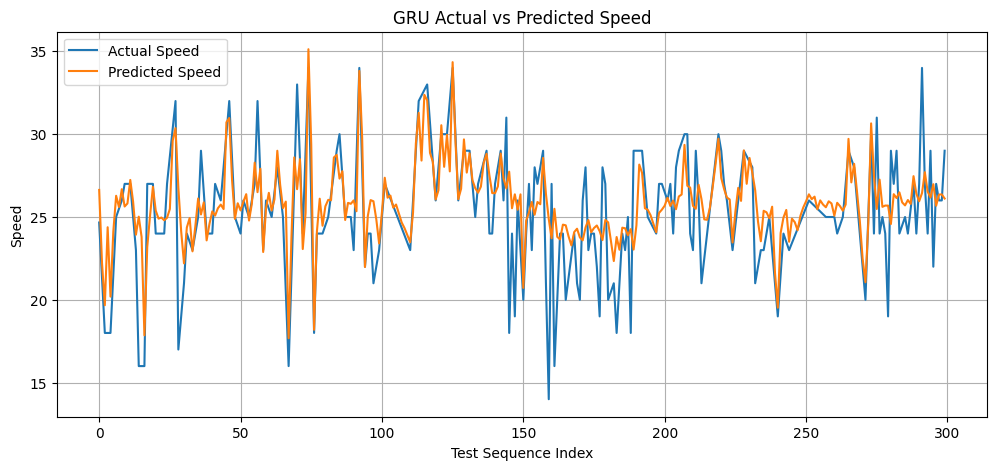

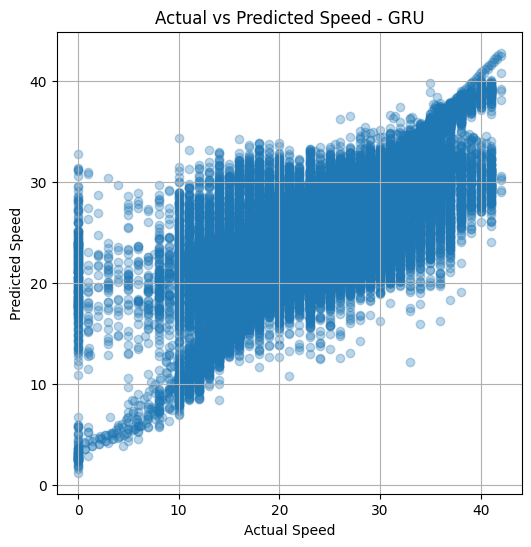

Saved test predictions to:
/content/drive/MyDrive/datasets/gru_test_predictions.csv


In [ ]:

# 30. CREATE TEST SEQUENCES
# Converts test data into sequences using previous timesteps
# Prepares input (X_test) and target (y_test) for evaluation
# =========================================================
X_test, y_test = create_sequences_by_segment(
    test_df,
    feature_cols,
    target_col,
    sequence_length
)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)



# 31. TEST PREDICTION
# Uses trained GRU model to predict speeds on test data
# Converts scaled values back to original speed units
# =========================================================
test_pred_scaled = model.predict(X_test)

y_test_original = target_scaler.inverse_transform(y_test.reshape(-1, 1))
test_pred_original = target_scaler.inverse_transform(test_pred_scaled)



# 32. TEST EVALUATION
# Computes performance metrics on test data
# MSE, RMSE, MAE, and R² evaluate prediction accuracy
# =========================================================
test_mse = mean_squared_error(y_test_original, test_pred_original)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test_original, test_pred_original)
test_r2 = r2_score(y_test_original, test_pred_original)

print("\nTest Results (predicting 10 mins)")
print("------------")
print(f"MSE  : {test_mse:.4f}")
print(f"RMSE : {test_rmse:.4f}")
print(f"MAE  : {test_mae:.4f}")
print(f"R²   : {test_r2:.4f}")


# 33. ACTUAL VS PREDICTED PLOT
# Plots actual vs predicted speeds over time
# Helps visualize how well the model follows real traffic patterns
# =========================================================
plt.figure(figsize=(12, 5))
plt.plot(y_test_original[:300], label='Actual Speed')
plt.plot(test_pred_original[:300], label='Predicted Speed')
plt.xlabel('Test Sequence Index')
plt.ylabel('Speed')
plt.title('GRU Actual vs Predicted Speed')
plt.legend()
plt.grid(True)
plt.show()


# 34. SCATTER PLOT: ACTUAL VS PREDICTED
# Compares actual vs predicted values
# Points close to diagonal indicate good predictions
# =========================================================
plt.figure(figsize=(6, 6))
plt.scatter(y_test_original, test_pred_original, alpha=0.3)
plt.xlabel('Actual Speed')
plt.ylabel('Predicted Speed')
plt.title('Actual vs Predicted Speed - GRU')
plt.grid(True)
plt.show()


# 35. SAVE TEST RESULTS TO CSV
# Saves actual, predicted, and error values to a CSV file
# Enables further analysis and reporting
# =========================================================
results_df = pd.DataFrame({
    'Actual_Speed': y_test_original.flatten(),
    'Predicted_Speed': test_pred_original.flatten(),
    'Error': y_test_original.flatten() - test_pred_original.flatten()
})

results_df.to_csv('/content/drive/MyDrive/datasets/gru_test_predictions.csv', index=False)

print("Saved test predictions to:")
print('/content/drive/MyDrive/datasets/gru_test_predictions.csv')